# Clustering

This notebook uses **k-means** to find groups of similar people in the Adult Income dataset.

- We try k = 2 to 10 clusters and compare them with the **Elbow method** and the **silhouette score**.
- For the chosen k we plot the clusters, show the centroids and interpret each cluster.

Clustering is unsupervised: `income` is not used to build the clusters. We only use it afterwards to check what the clusters mean.

## Getting ready

Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## Load the data

We use the cleaned training data from the descriptive statistics notebook (`cleaned_data/train_clean.csv`). The test data is not needed, because clustering has nothing to test.

In [2]:
train = pd.read_csv("cleaned_data/train_clean.csv")

print("Dataset shape:", train.shape)
display(train.head())

Dataset shape: (30139, 22)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,...,hours-per-week,native-country,income,capital-gain-log,capital-loss-log,capital-net,has-capital,is-married,age-group,hours-category
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,40,United-States,<=50K,7.684784,0.0,2174,1,0,35-44,Full-time
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,13,United-States,<=50K,0.000000,0.0,0,0,1,45-54,Part-time
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,40,United-States,<=50K,0.000000,0.0,0,0,0,35-44,Full-time
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,40,United-States,<=50K,0.000000,0.0,0,0,1,45-54,Full-time
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,40,Cuba,<=50K,0.000000,0.0,0,0,1,25-34,Full-time


## Choose the features

We describe every person with 7 features:

- `age`, `education-num`, `hours-per-week`
- `capital-gain-log`, `capital-loss-log` (the log versions, because the original values are very skewed)
- `sex` (1 = Male, 0 = Female)
- `is-married` (1 = married and living with the spouse)

We don't use the one-hot columns (occupation, workclass, relationship, race). With about 40 extra 0/1 columns the distances would mostly depend on whether two people have the same job, and the clusters would be very hard to interpret.

In [3]:
cluster_features = [
    "age",
    "education-num",
    "hours-per-week",
    "capital-gain-log",
    "capital-loss-log",
    "sex",
    "is-married"
]

X = train[cluster_features].copy()
X["sex"] = (X["sex"] == "Male").astype(int)

display(X.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
age,30139.0,38.442,13.131,17.0,28.0,37.0,47.0,90.000
education-num,30139.0,10.123,2.549,1.0,9.0,10.0,13.0,16.000
hours-per-week,30139.0,40.935,11.979,1.0,40.0,40.0,45.0,99.000
capital-gain-log,30139.0,0.744,2.471,0.0,0.0,0.0,0.0,11.513
capital-loss-log,30139.0,0.355,1.596,0.0,0.0,0.0,0.0,8.380
sex,30139.0,0.676,0.468,0.0,0.0,1.0,1.0,1.000
is-married,30139.0,0.467,0.499,0.0,0.0,0.0,1.0,1.000


## Standardization

k-means uses distances, so all features are standardized to mean 0 and standard deviation 1. Otherwise `age` (17-90) would count much more than `sex` (0 or 1).

In [4]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=cluster_features)

display(X_scaled.describe().T[["mean", "std"]].round(3))

,mean,std
age,0.0,1.0
education-num,0.0,1.0
hours-per-week,-0.0,1.0
capital-gain-log,-0.0,1.0
capital-loss-log,-0.0,1.0
sex,-0.0,1.0
is-married,0.0,1.0


## k-means for k = 2 to 10

For every k we save:

- Inertia: the sum of squared distances of the points to their centroid. It always gets smaller when k grows, so we look for the "elbow" where it stops dropping fast.
- Silhouette score: how well each point fits its own cluster compared to the nearest other cluster (from -1 to 1, higher is better). It is calculated on a random sample of 5,000 people, because the full calculation compares every pair of people and is very slow.

In [5]:
k_values = range(2, 11)

results = []

for k in k_values:

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)

    results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette
    })

results = pd.DataFrame(results).set_index("k")

display(results.round(4))

,Inertia,Silhouette
k,,
2,168859.5929,0.2390
3,140253.4260,0.2686
4,113625.0774,0.3004
5,95448.9484,0.3165
6,87403.0779,0.2870
7,80630.7116,0.2937
8,75444.5252,0.2844
9,70491.1920,0.2872
10,67602.5609,0.2738


#### Elbow method and silhouette score

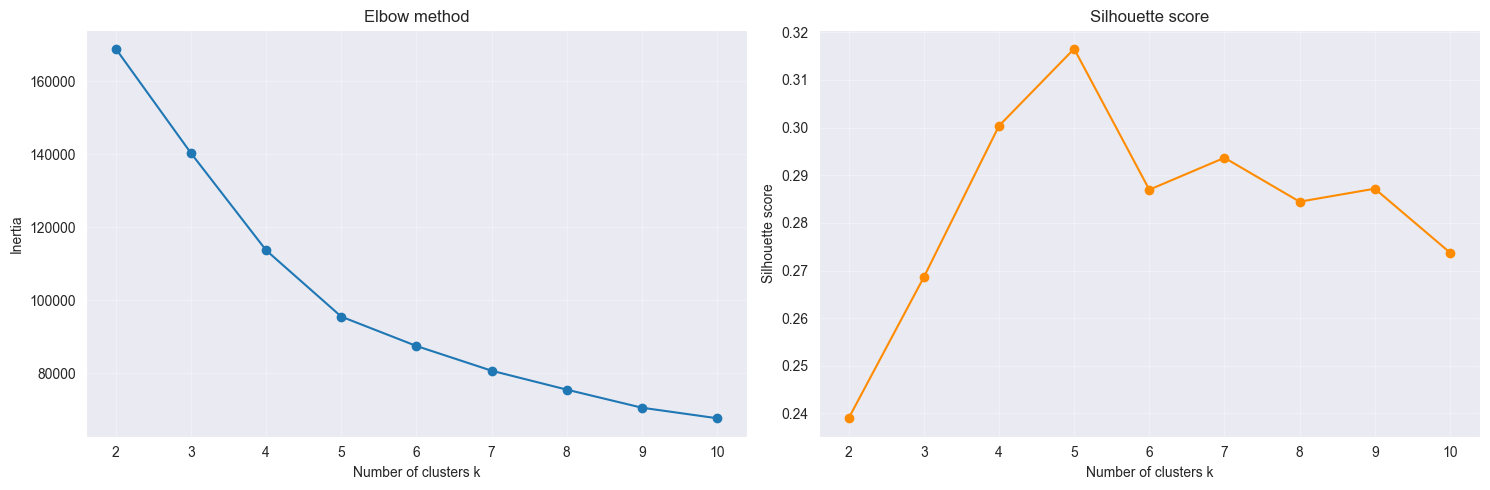

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(results.index, results["Inertia"], marker="o")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results.index, results["Silhouette"], marker="o", color="darkorange")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Choosing k

- Elbow method: the inertia drops by about 27,000 for every extra cluster up to k = 4, by 18,000 from k = 4 to k = 5, and after that only by 8,000 or less. So after k = 5 more clusters don't help much, the "elbow" is at k = 5.
- Silhouette score: the highest value is at k = 5 (0.317), the second highest at k = 4 (0.300).

Both methods point to `k = 5`, so we use 5 clusters.

A silhouette score of about 0.3 means the clusters are only moderately separated: people don't form completely separate groups, but the clusters are still clearly different from each other.

In [7]:
CHOSEN_K = 5

kmeans = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE)
train["cluster"] = kmeans.fit_predict(X_scaled)

cluster_sizes = train["cluster"].value_counts().sort_index().to_frame("People")
cluster_sizes["Percentage (%)"] = cluster_sizes["People"] / len(train) * 100

display(cluster_sizes.round(2))

,People,Percentage (%)
cluster,,
0,6984,23.17
1,1427,4.73
2,2501,8.30
3,8793,29.17
4,10434,34.62


## Plot of the clusters

The data has 7 features, so it can't be drawn directly. PCA (principal component analysis) turns the 7 features into 2 new axes that keep as much of the variation as possible, so the clusters can be shown in 2D. The centroids are marked with an X.

Share of the variation shown in the plot: 41.7 %


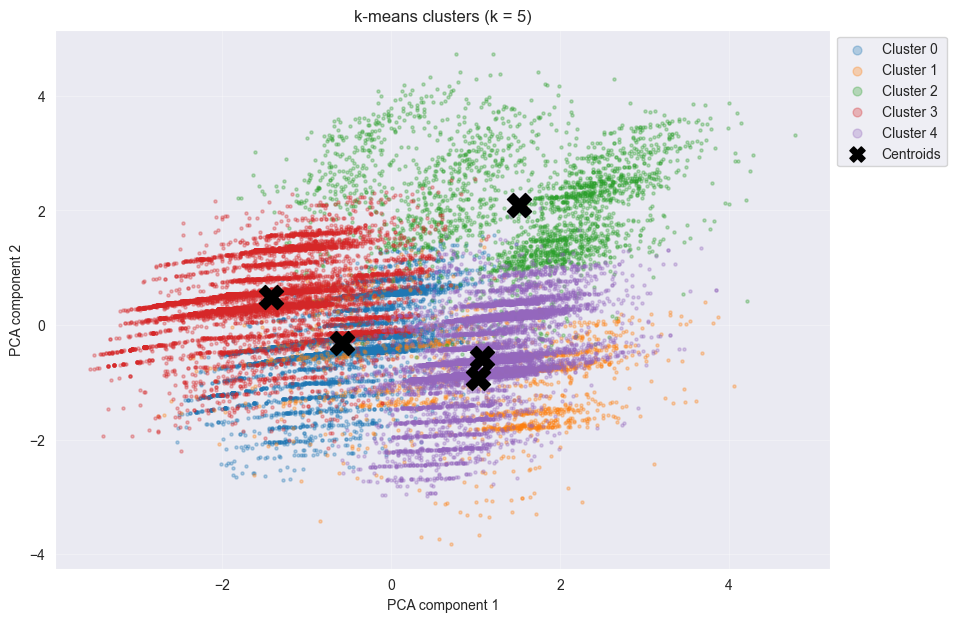

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
points_2d = pca.fit_transform(X_scaled)
centroids_2d = pca.transform(pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features))

print("Share of the variation shown in the plot:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

plt.figure(figsize=(10, 7))

for cluster in range(CHOSEN_K):
    in_cluster = train["cluster"] == cluster
    plt.scatter(points_2d[in_cluster, 0], points_2d[in_cluster, 1], s=5, alpha=0.3, label=f"Cluster {cluster}")

plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker="X", s=300, c="black", label="Centroids")

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title(f"k-means clusters (k = {CHOSEN_K})")
legend = plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
for handle in legend.legend_handles[:-1]:
    handle.set_sizes([40])     # bigger dots in the legend, the centroid marker stays as it is
handle_centroid = legend.legend_handles[-1]
handle_centroid.set_sizes([120])
plt.grid(True, alpha=0.3)
plt.show()

## Centroids

The centroid is the "average person" of each cluster. First in standardized units (0 = the average of all people, +1 = one standard deviation above the average), which shows what makes each cluster different. Then in the original units, which are easier to read.

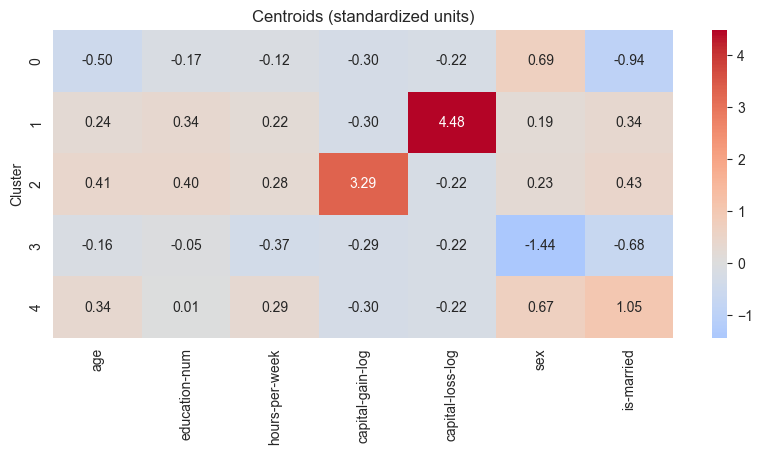

In [9]:
centroids_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
centroids_scaled.index.name = "Cluster"

plt.figure(figsize=(10, 4))
sns.heatmap(centroids_scaled, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Centroids (standardized units)")
plt.show()

In [10]:
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=cluster_features)
centroids.index.name = "Cluster"

# Back from log(1 + x) to the original amounts
centroids["capital-gain (approx.)"] = np.expm1(centroids["capital-gain-log"]).clip(lower=0)
centroids["capital-loss (approx.)"] = np.expm1(centroids["capital-loss-log"]).clip(lower=0)

display(centroids.round(2))

,age,education-num,hours-per-week,capital-gain-log,capital-loss-log,sex,is-married,capital-gain (approx.),capital-loss (approx.)
Cluster,,,,,,,,,
0,31.85,9.70,39.51,0.01,-0.00,1.00,0.00,0.01,0.0
1,41.65,10.99,43.55,0.00,7.51,0.76,0.64,0.00,1822.1
2,43.78,11.15,44.30,8.88,-0.00,0.79,0.68,7151.44,0.0
3,36.32,9.99,36.52,0.02,-0.00,0.00,0.13,0.02,0.0
4,42.92,10.15,44.45,0.00,-0.00,0.99,0.99,0.00,0.0


#### Cluster profiles

The centroid of a 0/1 feature is the share of people with 1, for example `sex` = 0.85 means 85% men. Below are the profiles of the clusters in the original units, and the share of people earning more than 50K. Income was **not** used for the clustering.

In [11]:
train["sex-male"] = (train["sex"] == "Male").astype(int)
train["income-over-50K"] = (train["income"] == ">50K").astype(int)

profile = train.groupby("cluster").agg(
    people=("age", "size"),
    age=("age", "mean"),
    education_num=("education-num", "mean"),
    hours_per_week=("hours-per-week", "mean"),
    has_capital=("has-capital", "mean"),
    male=("sex-male", "mean"),
    married=("is-married", "mean"),
    income_over_50K=("income-over-50K", "mean")
)

display(profile.round(3))

print("Share earning >50K in all training data:", round(train["income-over-50K"].mean(), 3))

,people,age,education_num,hours_per_week,has_capital,male,married,income_over_50K
cluster,,,,,,,,
0,6984,31.852,9.698,39.512,0.002,1.000,0.000,0.061
1,1427,41.647,10.993,43.549,1.000,0.764,0.636,0.516
2,2501,43.784,11.149,44.296,1.000,0.785,0.684,0.638
3,8793,36.319,9.993,36.516,0.003,0.000,0.127,0.082
4,10434,42.922,10.150,44.447,0.000,0.990,0.992,0.386


Share earning >50K in all training data: 0.249


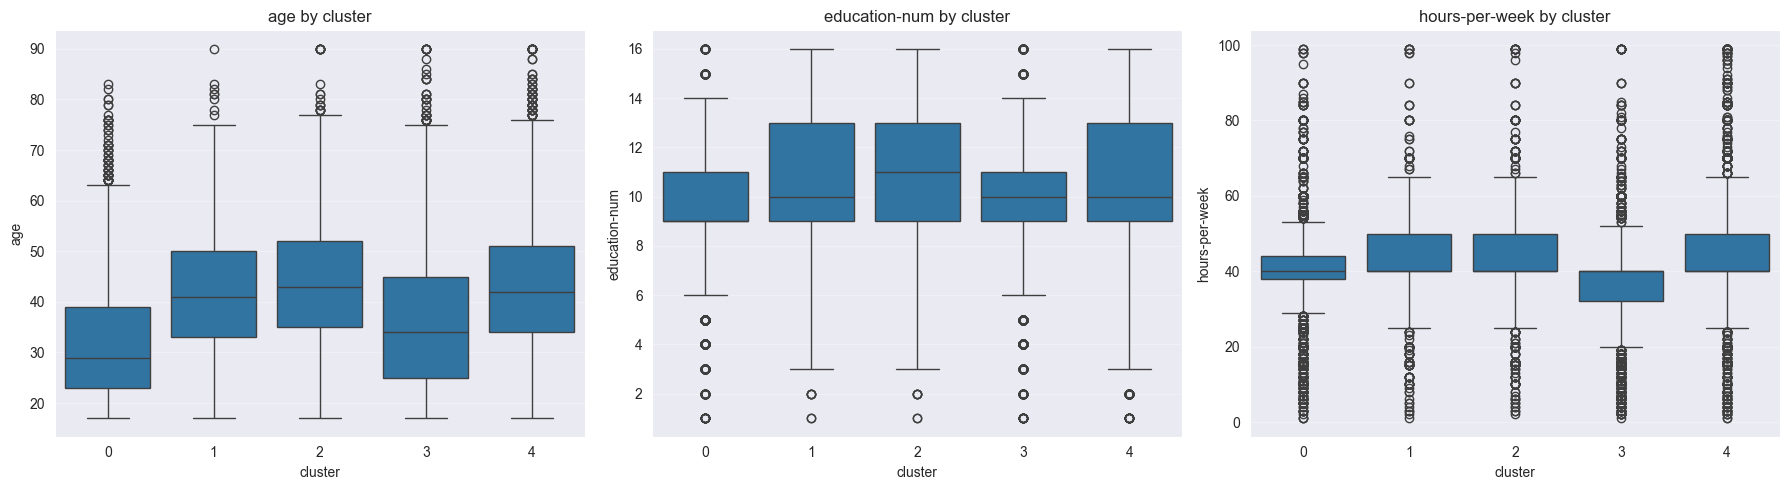

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, ["age", "education-num", "hours-per-week"]):
    sns.boxplot(data=train, x="cluster", y=column, ax=ax)
    ax.set_title(f"{column} by cluster")
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

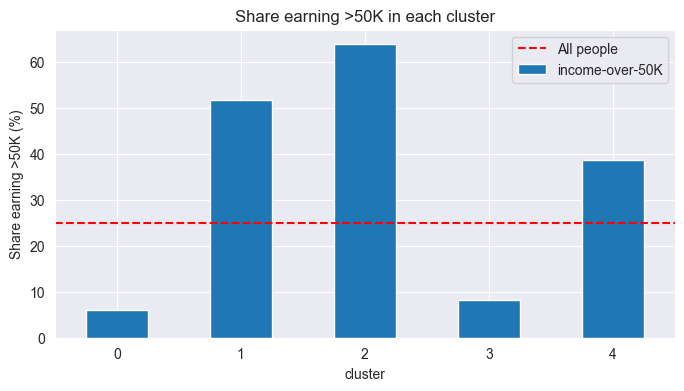

In [13]:
income_share = train.groupby("cluster")["income-over-50K"].mean() * 100

plt.figure(figsize=(8, 4))
income_share.plot.bar(rot=0)
plt.axhline(train["income-over-50K"].mean() * 100, color="red", linestyle="--", label="All people")
plt.ylabel("Share earning >50K (%)")
plt.title("Share earning >50K in each cluster")
plt.legend()
plt.show()

## Interpretation of the clusters

| Cluster | Size | Who they are | Earn >50K |
|---|---|---|---|
| 0 | 6,984 (23%) | Young single men: about 32 years old, all men, none married, no capital gains or losses | 6.1% |
| 1 | 1,427 (5%) | People with a capital loss (on average about 1,800): about 42 years old, 76% men, 64% married | 51.6% |
| 2 | 2,501 (8%) | People with a capital gain (on average about 7,150): about 44 years old, the highest education (11.1), 79% men, 68% married | 63.8% |
| 3 | 8,793 (29%) | Women, mostly not married: about 36 years old, all women, 13% married, the fewest working hours (36.5 h) | 8.2% |
| 4 | 10,434 (35%) | Married men: about 43 years old, 99% men, 99% married, about 44 working hours | 38.6% |

- The clusters are mostly formed by **sex, marital status and capital**. These are 0/1 features or features that are 0 for most people, so they split the data very clearly, while age, education and hours change more gradually between the clusters.
- Even though income was not used, the clusters are very different in income: from 6.1% (young single men) to 63.8% (people with capital gains), compared to 24.9% for all people. The two clusters with investments (1 and 2) and the married men (4) are the high-income groups.
- This matches the descriptive statistics: being married and having capital gains were the features most correlated with income.
- The PCA plot shows only 41.7% of the variation of the 7 features, so clusters that overlap in the plot can still be separated in the full data.

## Summary

- We clustered the 30,139 people of the training data with k-means, using 7 standardized features: age, education-num, hours-per-week, capital-gain-log, capital-loss-log, sex and is-married.
- We tried k = 2 to 10. The Elbow method and the silhouette score both chose **k = 5** (silhouette 0.317).
- The 5 clusters are: young single men, women (mostly not married), married men, people with a capital gain and people with a capital loss.
- The share of people earning more than 50K is very different between the clusters (6.1% to 63.8%), even though income was not used for the clustering. So the clusters describe real differences between groups of people.
- Limitation: the binary features (sex, is-married) and the capital features have a strong effect on the clusters. With other features (for example occupation) the clusters could look different.